# Understanding Gradients and Autograd in PyTorch

This notebook explores the concept of gradients and how PyTorch's autograd engine automatically computes them. We'll start with manual differentiation examples and then move to PyTorch's capabilities.

## 1. Manual Differentiation (Analytical Gradients)

Before diving into automatic differentiation, let's look at how we would compute derivatives analytically for simple functions.

### Example 1: $y = x^2$

If $y = x^2$, then $\frac{dy}{dx} = 2x$.

In [ ]:
def dy_dx(x):
  return 2*x

print(f"Derivative of x^2 at x=3: {dy_dx(3)}")

Derivative of x^2 at x=3: 6


### Example 2: $$\begin{align*} y &= x^2 \\ z &= \sin(y) \end{align*}$$

For $z = \sin(x^2)$, we can define an intermediate variable $y$:
$$ y = x^2 $$
$$ z = \sin(y) $$
Using the chain rule, we have: $\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} = \cos(y) \cdot 2x = 2x \cos(x^2)$

In [ ]:
import math

def dz_dx(x):
    return 2 * x * math.cos(x**2)

print(f"Derivative of sin(x^2) at x=2: {dz_dx(2)}")
print(f"Derivative of sin(x^2) at x=3: {dz_dx(3)}")

Derivative of sin(x^2) at x=2: -2.6145744834544478
Derivative of sin(x^2) at x=3: -5.466781571308061


## 2. Introduction to PyTorch Autograd

PyTorch's `autograd` package provides automatic differentiation for all operations on Tensors. It's a define-by-run framework, meaning your backprop graph is built on the fly as your code is executed.

In [ ]:
import torch

### Key Concept: `requires_grad=True`

To track gradients for a tensor, you need to set `requires_grad=True` when creating it or later using `tensor.requires_grad_(True)`.

In [ ]:
# Create a tensor 'x' that we want to track gradients for
x = torch.tensor(3.0, requires_grad=True)
print(f"Initial x: {x}")
x

Initial x: 3.0


tensor(3., requires_grad=True)

### Autograd for $y = x^2$

In [ ]:
## understand the computqational graph
y = x**2
y

tensor(9., grad_fn=<PowBackward0>)

In [ ]:
# Define a computation 'y'
y = x**2
print(f"y = x^2: {y}")

# Compute gradients by calling .backward() on a scalar tensor
y.backward()

# The gradient dy/dx is stored in x.grad
print(f"Gradient dy/dx at x=3: {x.grad}")

y = x^2: 9.0
Gradient dy/dx at x=3: 6.0


### Autograd for
### $$\begin{align*} y &= x^2 \\ z &= \sin(y) \end{align*}$$


In [ ]:
# Reset x and define a new computation
x = torch.tensor(3.0, requires_grad=True)
print(f"Initial x: {x}")

y = x ** 2
y


Initial x: 3.0


tensor(9., grad_fn=<PowBackward0>)

In [ ]:
z = torch.sin(y)
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [ ]:
print(f"y = x^2: {y}")
print(f"z = sin(y): {z}")

# Compute gradients for z with respect to x
z.backward()

# The gradient dz/dx is stored in x.grad
print(f"Gradient dz/dx at x=3: {x.grad}")

y = x^2: 9.0
z = sin(y): 0.41211849451065063
Gradient dz/dx at x=3: -5.4667816162109375


## 3. Binary Cross-Entropy (BCE) Loss and Gradients

This section demonstrates calculating gradients for Binary Cross-Entropy loss, first manually derived and then using PyTorch's autograd.

$$ z = wx + b $$
$$ y_{pred} = \sigma(z) = \frac{1}{1 + e^{-z}} $$
$$ L = -[y\log\left( \; y_{pred} \; \right) + (1-y)\log\left( \; 1-y_{pred} \; \right)] $$
$$ L = -[\text{Actual}\cdot\log\left( \; \text{Predicted} \; \right) + (1-\text{Actual})\cdot\log\left( \; 1-\text{Predicted} \; \right)] $$

$$
w \longrightarrow z \longrightarrow Y_{\text{pred}} \longrightarrow L
$$

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial z} \cdot \frac{\partial z}{\partial w} $$
$$ \frac{\partial L}{\partial y_{pred}} = \frac{y_{pred}-y}{y_{pred}(1-y_{pred})} $$
$$ \frac{\partial y_{pred}}{\partial z} = y_{pred}(1-y_{pred}) $$
$$ \frac{\partial z}{\partial w} = x $$
$$ \frac{\partial z}{\partial b} = 1 $$
$$
b \longrightarrow z \longrightarrow Y_{\text{pred}} \longrightarrow L
$$

$$ \frac{\partial L}{\partial b} = \frac{\partial L}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial z} \cdot \frac{\partial z}{\partial b} $$

$$ \frac{\partial L}{\partial w} = (y_{pred}-y)x $$
$$ \frac{\partial L}{\partial b} = (y_{pred}-y) $$

In [ ]:
import torch

# Binary Cross-Entropy Loss function
def binary_cross_entropy_loss(prediction, target):
    epsilon = 1e-8  # To prevent log(0) issues
    prediction = torch.clamp(prediction, epsilon, 1 - epsilon)
    return -(target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction))

# Inputs
x = torch.tensor(6.7)  # Input feature
y = torch.tensor(0.0)  # True label (binary)

w = torch.tensor(1.0)  # Weight
b = torch.tensor(0.0)  # Bias

### Manual Gradient Calculation for BCE Loss

In [ ]:
# Forward pass
z = w * x + b  # Weighted sum (linear part)
y_pred = torch.sigmoid(z)  # Predicted probability

# Compute binary cross-entropy loss
loss = binary_cross_entropy_loss(y_pred, y)
print(f"Calculated Loss: {loss}")

# Derivatives based on the formulas derived above:
# 1. dL/d(y_pred): Loss with respect to the prediction (y_pred)
dloss_dy_pred = (y_pred - y)/(y_pred*(1-y_pred))

# 2. dy_pred/dz: Prediction (y_pred) with respect to z (sigmoid derivative)
dy_pred_dz = y_pred * (1 - y_pred)

# 3. dz/dw and dz/db: z with respect to w and b
dz_dw = x  # dz/dw = x
dz_db = torch.tensor(1.0)  # dz/db = 1 (bias contributes directly to z)

# Chain rule to get dL/dw and dL/db
dL_dw_manual = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db_manual = dloss_dy_pred * dy_pred_dz * dz_db

print(f"\nManual Gradient of loss w.r.t weight (dL/dw): {dL_dw_manual}")
print(f"Manual Gradient of loss w.r.t bias (dL/db): {dL_db_manual}")

Calculated Loss: 6.701176166534424

Manual Gradient of loss w.r.t weight (dL/dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (dL/db): 0.998770534992218


### PyTorch Autograd for BCE Loss

In [ ]:
# Inputs (resetting to track gradients for w and b)
x = torch.tensor(6.7)
y = torch.tensor(0.0)

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Forward pass with autograd enabled
z = w * x + b
y_pred = torch.sigmoid(z)
loss = binary_cross_entropy_loss(y_pred, y)

# Perform backward pass to compute gradients
loss.backward()

# Gradients are now stored in w.grad and b.grad
print(f"\nPyTorch Autograd Gradient of loss w.r.t weight (w.grad): {w.grad}")
print(f"PyTorch Autograd Gradient of loss w.r.t bias (b.grad): {b.grad}")


PyTorch Autograd Gradient of loss w.r.t weight (w.grad): 6.6917619705200195
PyTorch Autograd Gradient of loss w.r.t bias (b.grad): 0.9987704753875732


Notice that the gradients computed manually and by PyTorch's autograd are identical, confirming the correctness of the autograd engine.

## 4. Gradient Accumulation and Zeroing

By default, PyTorch accumulates gradients. This means if you call `backward()` multiple times without zeroing the gradients, they will add up. This can be useful for tasks like accumulating gradients over mini-batches before a single optimization step, but often you want to reset them for each new backward pass.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [ ]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [ ]:
y.backward()

In [ ]:
x.grad

tensor(4.)

In [ ]:
x.grad.zero_()

tensor(0.)

In [ ]:
# Create a tensor with requires_grad=True
x = torch.tensor(2.0, requires_grad=True)
print(f"Initial x: {x}")

# First forward and backward pass
y = x ** 2 # y = 4
y.backward()
print(f"x.grad after first backward (y=x^2): {x.grad}") # Should be 2*x = 4

# Second forward and backward pass WITHOUT zeroing gradients
y = x ** 2 # y = 4 (same computation, but gradients will accumulate)
y.backward()
print(f"x.grad after second backward (gradients accumulated): {x.grad}") # Should be 4 + 4 = 8

# Zeroing the gradients
x.grad.zero_() # In-place operation to set gradients to zero
print(f"x.grad after zeroing: {x.grad}")

# Third forward and backward pass AFTER zeroing gradients
y = x ** 2 # y = 4
y.backward()
print(f"x.grad after third backward (gradients reset): {x.grad}") # Should be 2*x = 4

Initial x: 2.0
x.grad after first backward (y=x^2): 4.0
x.grad after second backward (gradients accumulated): 8.0
x.grad after zeroing: 0.0
x.grad after third backward (gradients reset): 4.0


## 5. Disabling Gradient Tracking

There are scenarios where you might want to temporarily disable gradient tracking, such as during evaluation, inference, or when freezing parts of a model. This saves memory and computation.

### Option 1: `tensor.requires_grad_(False)`

This method changes the `requires_grad` attribute of a tensor in-place. If any tensor involved in a computation has `requires_grad=False`, then the output tensor will also have `requires_grad=False`.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y=x**2
print(y.grad_fn)

In [ ]:
x = torch.tensor(2.0, requires_grad=False)
y=x**2
print(y.grad_fn)

None


In [ ]:
x = torch.tensor(2.0, requires_grad=True)
print(f"x before disabling grad: {x} (requires_grad={x.requires_grad})")

x.requires_grad_(False) # Disable gradient tracking in-place
print(f"x after disabling grad: {x} (requires_grad={x.requires_grad})")

y = x ** 2
print(f"y = x^2: {y} (requires_grad={y.requires_grad})")

print("None Output means PyTorch does not created a backward function for the power operation. :",y.grad_fn)

try:
    y.backward() # This will raise an error because y does not require grad
except RuntimeError as e:
    print(f"\nError trying to call backward(): {e}")

x before disabling grad: 2.0 (requires_grad=True)
x after disabling grad: 2.0 (requires_grad=False)
y = x^2: 4.0 (requires_grad=False)
None Output means PyTorch does not created a backward function for the power operation. : None

Error trying to call backward(): element 0 of tensors does not require grad and does not have a grad_fn


### Option 2: `tensor.detach()`
- disconnects a tensor from the graph
- x ----> detach() ----> x_detached ----> y_nograd
(graph cut here)


`detach()` creates a new tensor that shares the same storage with the original tensor but does not participate in the gradient computation graph. It effectively 'detaches' the tensor from the graph.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
print(f"x (original): {x} (requires_grad={x.requires_grad})")

z = x.detach() # Create a new tensor 'z' detached from the graph
print(f"z (detached from x): {z} (requires_grad={z.requires_grad})")

# y depends on x (which still requires grad)
y = x ** 2
print(f"y = x^2 (depends on original x): {y} (requires_grad={y.requires_grad})")

# y1 depends on z (which does NOT require grad)
y1 = z ** 2
print(f"y1 = z^2 (depends on detached z): {y1} (requires_grad={y1.requires_grad})")

# Backward on 'y' works as 'x' still tracks gradients
y.backward()
print(f"\nx.grad after y.backward(): {x.grad}")

# Backward on 'y1' will raise an error as 'z' does not require grad
try:
    y1.backward()
except RuntimeError as e:
    print(f"Error trying to call y1.backward(): {e}")

x (original): 2.0 (requires_grad=True)
z (detached from x): 2.0 (requires_grad=False)
y = x^2 (depends on original x): 4.0 (requires_grad=True)
y1 = z^2 (depends on detached z): 4.0 (requires_grad=False)

x.grad after y.backward(): 4.0
Error trying to call y1.backward(): element 0 of tensors does not require grad and does not have a grad_fn


### Option 3: `with torch.no_grad():`
- disables graph recording globally inside the block

This is often the preferred method for disabling gradient tracking during inference or when initializing model parameters. Any computations performed within this context manager will not have their gradients tracked.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
print(f"x before no_grad: {x} (requires_grad={x.requires_grad})")

with torch.no_grad():
    # Computation inside no_grad block
    y_nograd = x ** 2 # Define y_nograd here

    print(f"y_nograd = x^2 (inside no_grad block): {y_nograd} (requires_grad={y_nograd.requires_grad})")

    # Attempting to call backward on y_nograd will raise an error
    try:
        y_nograd.backward()
    except RuntimeError as e:
        print(f"Error trying to call y_nograd.backward(): {e}")

    # The original tensor 'x' still has requires_grad=True, but 'y_nograd' does not depend on it for gradient tracking.
    print(f"x.grad remains None if no other operation required it: {x.grad}")

x before no_grad: 2.0 (requires_grad=True)
y_nograd = x^2 (inside no_grad block): 4.0 (requires_grad=False)
Error trying to call y_nograd.backward(): element 0 of tensors does not require grad and does not have a grad_fn
x.grad remains None if no other operation required it: None


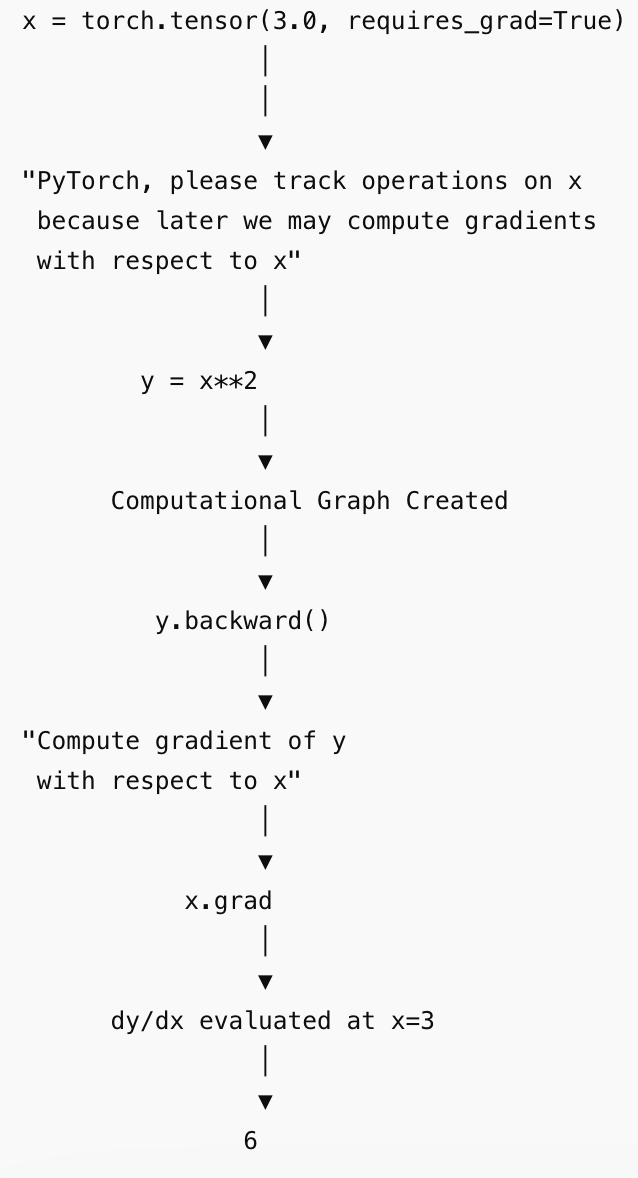

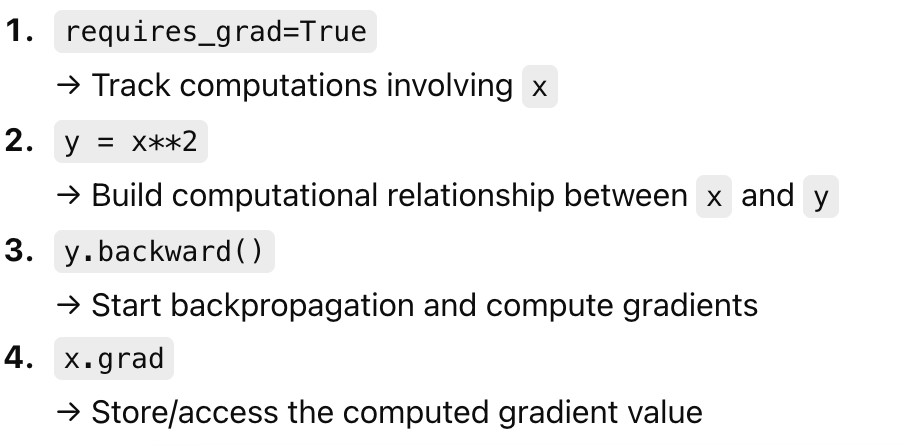